In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os, re

In [2]:
# Grab all files, radii, and heights
sim_data_path = Path("./simulation_data").resolve()
entries = []
for file in sim_data_path.glob("R*H*F*.csv"):
    pattern = r"R(\d+)_H(\d+)_F(\d+)"
    match = re.search(pattern, str(file))
    if match:
        radius = match.group(1)
        height = match.group(2)
        fidelity = match.group(3)
        entries.append((file, int(radius), int(height), fidelity))

### Source Distributions

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

bins_r = np.linspace(0, 1.5, num=21)
bins_z = np.linspace(-1.5, 1.5, num=41)
counts_r = np.zeros(len(bins_r) - 1)
counts_z = np.zeros(len(bins_z) - 1)

for entry in entries:
    file = entry[0]
    radius = entry[1]
    height = entry[2]
    if os.path.exists(file):
        df = pd.read_csv(file, usecols=["x", "y", "z"])
        radii_data = np.sqrt(((df["x"].drop_duplicates())**2. + (df["y"].drop_duplicates())**2)) / radius
        counts_r += np.histogram(radii_data, bins=bins_r)[0]
        z_data = df["z"].dropna().drop_duplicates() / height
        counts_z += np.histogram(z_data, bins=bins_z)[0]

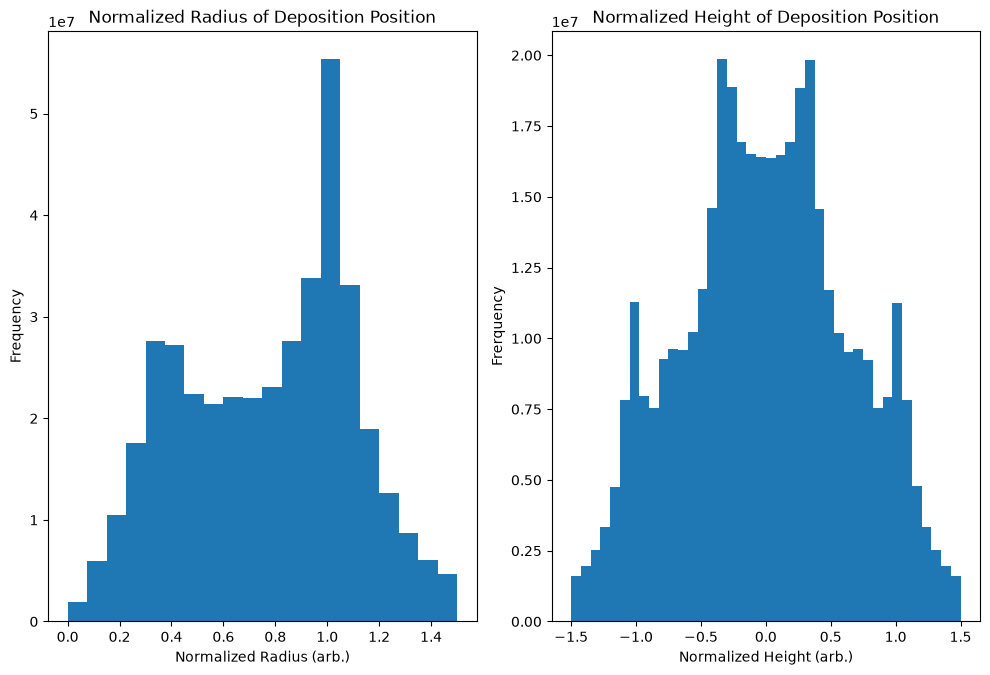

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7))

ax1.stairs(counts_r, bins_r, fill=True)
ax1.set_xlabel("Normalized Radius (arb.)")
ax1.set_ylabel('Frequency')
ax1.set_title("Normalized Radius of Deposition Position")

ax2.stairs(counts_z, bins_z, fill=True)
ax2.set_xlabel("Normalized Height (arb.)")
ax2.set_ylabel('Frerquency')
ax2.set_title("Normalized Height of Deposition Position")

plt.tight_layout()
plt.show()

### Bytes / Event Distribution

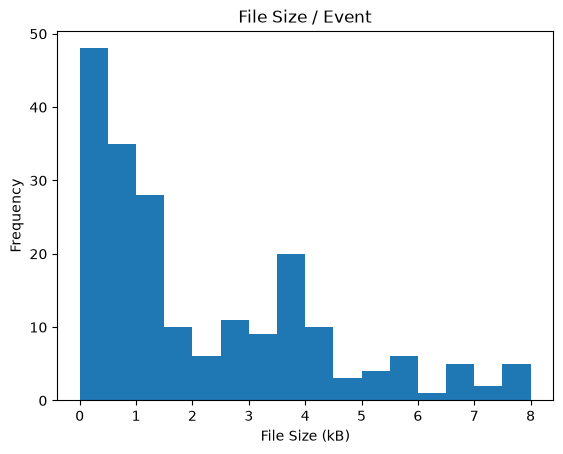

In [5]:
lf_size = 100000
hf_size = 1000000
sizes = []
for entry in entries:
    file = entry[0]
    fidelity = entry[3]
    size = file.stat().st_size / 1024
    if fidelity == 1:
        size /= hf_size
    else:
        size /= lf_size
    sizes.append(size)
    
bins = np.linspace(0, 8, num=17)
plt.hist(sizes, bins=bins)
plt.title("File Size / Event")
plt.xlabel("File Size (kB)")
plt.ylabel("Frequency")
plt.show()